# Spotter Freight Rate Prediction - Kaggle Workflow

This notebook:

1. Loads the supplied Spotter assessment files.
2. Performs lightweight data-quality checks.
3. Cleans `weight` without dropping rows.
4. Uses **chronological validation** because training ends in October 2025 and the hidden validation set covers November-December 2025.
5. Trains a LightGBM regression model.
6. Generates:
   - `validation_predictions.csv`
   - completed `december_chart_inputs.csv`
7. Runs the supplied `score.py`.
8. Saves a feature-importance figure and trained model for reproducibility.

**Important:** Do not use a random train/validation split for the main reported metric.

> **Dependency compliance:** The first code cell installs and verifies Spotter's exact
> `matplotlib`, `numpy`, and `pandas` version constraints before any modeling begins.


In [1]:
# ============================================================
# 0. Install and verify dependencies
# ============================================================
# Spotter's supplied requirements.txt requires:
#   matplotlib>=3.8,<4
#   numpy>=1.26,<3
#   pandas>=2.0,<3
#
# We also install LightGBM and scikit-learn because this notebook
# uses them for the ML workflow.

import sys
import subprocess

required_packages = [
    "matplotlib>=3.8,<4",
    "numpy>=1.26,<3",
    "pandas>=2.0,<3",
    "lightgbm>=4.0,<5",
    "scikit-learn>=1.4,<2",
]

subprocess.check_call(
    [sys.executable, "-m", "pip", "install", "-q", *required_packages]
)

# Verify the installed versions.
import matplotlib
import numpy as np
import pandas as pd
import lightgbm
import sklearn

from packaging.version import Version

assert Version("3.8") <= Version(matplotlib.__version__) < Version("4")
assert Version("1.26") <= Version(np.__version__) < Version("3")
assert Version("2.0") <= Version(pd.__version__) < Version("3")

print("Dependency check passed ✅")
print("matplotlib:", matplotlib.__version__)
print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("lightgbm:", lightgbm.__version__)
print("scikit-learn:", sklearn.__version__)

Dependency check passed ✅
matplotlib: 3.10.0
numpy: 2.0.2
pandas: 2.3.3
lightgbm: 4.6.0
scikit-learn: 1.6.1


In [3]:
import glob

# Find the uploaded files anywhere under /kaggle/input.
def find_file(filename):
    matches = glob.glob(f"/kaggle/input/**/{filename}", recursive=True)
    if not matches:
        raise FileNotFoundError(f"Could not find {filename} under /kaggle/input")
    return matches[0]

In [8]:
import os
import glob

# Show everything Kaggle actually mounted
print("Files found under /kaggle/input:\n")
for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        print(os.path.join(root, file))


def find_file(filename):
    matches = glob.glob(f"/kaggle/input/**/{filename}", recursive=True)

    if len(matches) == 0:
        raise FileNotFoundError(
            f"{filename} was not found.\n"
            f"Make sure the dataset containing it is added to this notebook."
        )

    if len(matches) > 1:
        print(f"Multiple matches for {filename}:")
        for m in matches:
            print("  ", m)

    print(f"Using {filename}: {matches[0]}")
    return matches[0]


TRAIN_PATH = find_file("train-test.csv")
VALID_PATH = find_file("validation.csv")
DECEMBER_PATH = find_file("december-chart-inputs.csv")
TEMPLATE_PATH = find_file("validation-predictions-template.csv")
SCORE_PATH = find_file("score.py")

print("\nFINAL PATHS")
print("TRAIN:", TRAIN_PATH)
print("VALIDATION:", VALID_PATH)
print("DECEMBER:", DECEMBER_PATH)
print("TEMPLATE:", TEMPLATE_PATH)
print("SCORE:", SCORE_PATH)

Files found under /kaggle/input:

/kaggle/input/datasets/mdraihansiddik/validations/validation-predictions-template.csv
/kaggle/input/datasets/mdraihansiddik/validation-main/validation.csv
/kaggle/input/datasets/mdraihansiddik/train-csv/train-test.csv
/kaggle/input/datasets/mdraihansiddik/december3/december-chart-inputs.csv
/kaggle/input/datasets/mdraihansiddik/python/score.py
Using train-test.csv: /kaggle/input/datasets/mdraihansiddik/train-csv/train-test.csv
Using validation.csv: /kaggle/input/datasets/mdraihansiddik/validation-main/validation.csv
Using december-chart-inputs.csv: /kaggle/input/datasets/mdraihansiddik/december3/december-chart-inputs.csv
Using validation-predictions-template.csv: /kaggle/input/datasets/mdraihansiddik/validations/validation-predictions-template.csv
Using score.py: /kaggle/input/datasets/mdraihansiddik/python/score.py

FINAL PATHS
TRAIN: /kaggle/input/datasets/mdraihansiddik/train-csv/train-test.csv
VALIDATION: /kaggle/input/datasets/mdraihansiddik/valid

In [9]:
train = pd.read_csv(TRAIN_PATH)
validation = pd.read_csv(VALID_PATH)
december = pd.read_csv(DECEMBER_PATH)
template = pd.read_csv(TEMPLATE_PATH)

print("train:", train.shape)
print("validation:", validation.shape)
print("december:", december.shape)
print("template:", template.shape)

display(train.head())

train: (48000, 14)
validation: (12000, 13)
december: (31, 7)
template: (12000, 2)


,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28


In [10]:
# Basic data audit
def audit(df, name):
    d = pd.to_datetime(df["date"])
    print(f"\n{name}")
    print("shape:", df.shape)
    print("date range:", d.min().date(), "to", d.max().date())
    print("missing values:")
    print(df.isna().sum()[df.isna().sum() > 0])
    if "weight" in df.columns:
        print("negative weights:", int((df["weight"] < 0).sum()))

audit(train, "TRAIN")
audit(validation, "VALIDATION")

print("\nTarget summary:")
display(train["posted_rate"].describe())


TRAIN
shape: (48000, 14)
date range: 2025-01-01 to 2025-10-31
missing values:
weight          300
market_index    374
dtype: int64
negative weights: 292

VALIDATION
shape: (12000, 13)
date range: 2025-11-01 to 2025-12-31
missing values:
weight          165
market_index    249
dtype: int64
negative weights: 145

Target summary:


count    48000.000000
mean      2373.980682
std       1486.493245
min         57.220000
25%       1251.555000
50%       2030.760000
75%       3330.750000
max      25533.000000
Name: posted_rate, dtype: float64

## Preprocessing choices

- Keep all training rows: 48k rows is small for Kaggle.
- Drop `load_id` from model features because it is an identifier.
- Convert negative weights to absolute values because physical shipment weight should not be negative.
- Impute missing weight using the **training-only median for each equipment type**.
- Do not use `market_index` or `quote_signal` in the main deployment model. They are absent from the December prediction file, and a deployment-consistent model avoids creating a second incompatible feature pipeline.
- Use coordinates instead of relying on pickup/delivery city labels, which also helps with cities that are not seen in training.
- Add cyclic date features and day-of-week because the evaluation period is in the future.

In [11]:
EQUIPMENT_LEVELS = sorted(train["equipment"].dropna().unique().tolist())

def fit_preprocessing_state(df):
    temp = df.copy()
    temp["weight_clean"] = temp["weight"].abs()
    weight_medians = temp.groupby("equipment")["weight_clean"].median().to_dict()
    overall_weight_median = float(temp["weight_clean"].median())

    # City-coordinate lookup built from development data only.
    pickups = temp[["pickup", "pickup_lat", "pickup_lon"]].rename(
        columns={"pickup": "city", "pickup_lat": "lat", "pickup_lon": "lon"}
    )
    deliveries = temp[["delivery", "delivery_lat", "delivery_lon"]].rename(
        columns={"delivery": "city", "delivery_lat": "lat", "delivery_lon": "lon"}
    )
    city_coords = (
        pd.concat([pickups, deliveries], ignore_index=True)
        .groupby("city")[["lat", "lon"]]
        .median()
    )
    return weight_medians, overall_weight_median, city_coords

def add_december_coordinates(df, city_coords):
    out = df.copy()
    out["pickup_lat"] = out["pickup"].map(city_coords["lat"])
    out["pickup_lon"] = out["pickup"].map(city_coords["lon"])
    out["delivery_lat"] = out["delivery"].map(city_coords["lat"])
    out["delivery_lon"] = out["delivery"].map(city_coords["lon"])

    needed = ["pickup_lat", "pickup_lon", "delivery_lat", "delivery_lon"]
    if out[needed].isna().any().any():
        missing_cities = sorted(
            set(out.loc[out["pickup_lat"].isna(), "pickup"]) |
            set(out.loc[out["delivery_lat"].isna(), "delivery"])
        )
        raise ValueError(f"Missing coordinates for: {missing_cities}")
    return out

FEATURES = [
    "distance",
    "weight_clean",
    "pickup_lat",
    "pickup_lon",
    "delivery_lat",
    "delivery_lon",
    "equipment",
    "month_sin",
    "month_cos",
    "doy_sin",
    "doy_cos",
    "dow",
    "lat_diff",
    "lon_diff",
]

def make_features(df, weight_medians, overall_weight_median):
    x = df.copy()
    dt = pd.to_datetime(x["date"])

    x["weight_clean"] = x["weight"].abs()
    x["weight_clean"] = x["weight_clean"].fillna(x["equipment"].map(weight_medians))
    x["weight_clean"] = x["weight_clean"].fillna(overall_weight_median)

    month = dt.dt.month
    doy = dt.dt.dayofyear

    x["month_sin"] = np.sin(2 * np.pi * month / 12.0)
    x["month_cos"] = np.cos(2 * np.pi * month / 12.0)
    x["doy_sin"] = np.sin(2 * np.pi * doy / 365.25)
    x["doy_cos"] = np.cos(2 * np.pi * doy / 365.25)
    x["dow"] = dt.dt.dayofweek

    x["lat_diff"] = x["delivery_lat"] - x["pickup_lat"]
    x["lon_diff"] = x["delivery_lon"] - x["pickup_lon"]

    X = x[FEATURES].copy()
    X["equipment"] = pd.Categorical(X["equipment"], categories=EQUIPMENT_LEVELS)
    return X

## Chronological validation

The hidden set is later in time, so the local validation should imitate that deployment setting.

Here we train on **January-August** and validate on **September-October**.

In [12]:
dev = train.copy()
dev["date_dt"] = pd.to_datetime(dev["date"])

train_part = dev[dev["date_dt"] < "2025-09-01"].copy()
valid_part = dev[dev["date_dt"] >= "2025-09-01"].copy()

weight_medians, overall_weight_median, _ = fit_preprocessing_state(train_part)

X_train = make_features(train_part, weight_medians, overall_weight_median)
X_valid = make_features(valid_part, weight_medians, overall_weight_median)
y_train = train_part["posted_rate"]
y_valid = valid_part["posted_rate"]

print("training rows:", len(train_part))
print("validation rows:", len(valid_part))
print("training through:", train_part["date_dt"].max().date())
print("validation:", valid_part["date_dt"].min().date(), "to", valid_part["date_dt"].max().date())

training rows: 38477
validation rows: 9523
training through: 2025-08-31
validation: 2025-09-01 to 2025-10-31


In [14]:
from lightgbm import LGBMRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

In [16]:
RANDOM_STATE = 42

In [17]:
model = LGBMRegressor(
    objective="regression_l1",
    n_estimators=600,
    learning_rate=0.03,
    num_leaves=31,
    reg_lambda=10.0,
    random_state=RANDOM_STATE,
    verbosity=-1,
)

model.fit(
    X_train,
    y_train,
    categorical_feature=["equipment"],
)

valid_pred = np.clip(model.predict(X_valid), 1.0, None)

mae = mean_absolute_error(y_valid, valid_pred)
rmse = mean_squared_error(y_valid, valid_pred) ** 0.5
mape = np.mean(np.abs((y_valid.to_numpy() - valid_pred) / y_valid.to_numpy())) * 100

print(f"MAE : ${mae:,.2f}")
print(f"RMSE: ${rmse:,.2f}")
print(f"MAPE: {mape:.2f}%")

MAE : $116.97
RMSE: $636.57
MAPE: 5.10%


In [24]:
import time
import lightgbm as lgb
from lightgbm import LGBMRegressor

model = LGBMRegressor(
    objective="regression_l1",
    n_estimators=600,
    learning_rate=0.03,
    num_leaves=31,
    reg_lambda=10.0,
    random_state=42,
    verbosity=1,
)

start = time.time()

model.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric="mae",
    categorical_feature=["equipment"],
    callbacks=[lgb.log_evaluation(50)]
)

print(f"\nTraining time: {time.time() - start:.2f} seconds")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000851 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1792
[LightGBM] [Info] Number of data points in the train set: 38477, number of used features: 14
[LightGBM] [Info] Start training from score 2026.040039
[50]	valid_0's l1: 346.171
[100]	valid_0's l1: 172.843
[150]	valid_0's l1: 133.867
[200]	valid_0's l1: 122.823
[250]	valid_0's l1: 118.884
[300]	valid_0's l1: 117.545
[350]	valid_0's l1: 117.149
[400]	valid_0's l1: 116.899
[450]	valid_0's l1: 116.806
[500]	valid_0's l1: 116.896
[550]	valid_0's l1: 116.792
[600]	valid_0's l1: 116.969

Training time: 2.10 seconds


In [20]:
import matplotlib.pyplot as plt

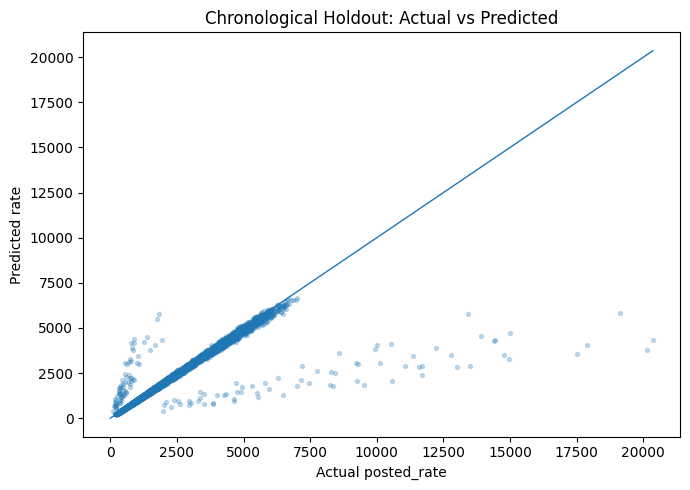

In [25]:
# Optional diagnostic plot
plt.figure(figsize=(7, 5))
plt.scatter(y_valid, valid_pred, s=8, alpha=0.25)
limit = max(y_valid.max(), valid_pred.max())
plt.plot([0, limit], [0, limit], linewidth=1)
plt.xlabel("Actual posted_rate")
plt.ylabel("Predicted rate")
plt.title("Chronological Holdout: Actual vs Predicted")
plt.tight_layout()
plt.show()

## Final fit on all 48,000 labeled rows

After model selection, refit preprocessing and the model on the complete development set.

In [26]:
final_weight_medians, final_weight_median, city_coords = fit_preprocessing_state(train)

X_all = make_features(train, final_weight_medians, final_weight_median)
y_all = train["posted_rate"]

final_model = LGBMRegressor(
    objective="regression_l1",
    n_estimators=600,
    learning_rate=0.03,
    num_leaves=31,
    reg_lambda=10.0,
    random_state=RANDOM_STATE,
    verbosity=-1,
)

final_model.fit(
    X_all,
    y_all,
    categorical_feature=["equipment"],
)

MODEL_PATH = "/kaggle/working/freight_rate_lgbm.txt"
final_model.booster_.save_model(MODEL_PATH)
print("saved:", MODEL_PATH)

saved: /kaggle/working/freight_rate_lgbm.txt


## Predict the 12,000 hidden validation loads

The template is filled **by `load_id`**, not by assuming row order.

In [27]:
X_test = make_features(validation, final_weight_medians, final_weight_median)
test_pred = np.clip(final_model.predict(X_test), 1.0, None)

prediction_map = pd.Series(test_pred, index=validation["load_id"]).to_dict()

submission = template.copy()
submission["predicted_rate"] = submission["load_id"].map(prediction_map)

assert list(submission.columns) == ["load_id", "predicted_rate"]
assert len(submission) == 12000
assert submission["load_id"].is_unique
assert submission["predicted_rate"].notna().all()
assert np.isfinite(submission["predicted_rate"]).all()
assert (submission["predicted_rate"] > 0).all()

VALIDATION_OUTPUT = "/kaggle/working/validation_predictions.csv"
submission.to_csv(VALIDATION_OUTPUT, index=False)

display(submission.head())
print("saved:", VALIDATION_OUTPUT)

,load_id,predicted_rate
0,TE-000001,809.471491
1,TE-000002,4929.726287
2,TE-000003,5098.764566
3,TE-000004,3876.838433
4,TE-000005,1797.275215


saved: /kaggle/working/validation_predictions.csv


## Predict the required December series

The December file omits latitude/longitude, so we derive Lexington and Fort Wayne coordinates from the labeled development data. The saved CSV keeps the **original seven columns and column order**.

In [28]:
dec_for_model = add_december_coordinates(december, city_coords)
X_dec = make_features(dec_for_model, final_weight_medians, final_weight_median)
dec_pred = np.clip(final_model.predict(X_dec), 1.0, None)

december_output = december.copy()
december_output["predicted_rate"] = dec_pred

expected_columns = [
    "pickup", "delivery", "distance", "equipment",
    "weight", "date", "predicted_rate"
]
assert list(december_output.columns) == expected_columns
assert len(december_output) == 31
assert december_output["predicted_rate"].notna().all()
assert (december_output["predicted_rate"] > 0).all()

DECEMBER_OUTPUT = "/kaggle/working/december_chart_inputs.csv"
december_output.to_csv(DECEMBER_OUTPUT, index=False)

display(december_output.head())
print("saved:", DECEMBER_OUTPUT)

,pickup,delivery,distance,equipment,weight,date,predicted_rate
0,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-01,786.350609
1,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-02,790.423150
2,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-03,795.432311
3,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-04,791.976453
4,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-05,787.706731


saved: /kaggle/working/december_chart_inputs.csv


In [29]:
# Run the exact scorer supplied by Spotter.
SCORER_DIR = "/kaggle/working/scorer_results"

cmd = [
    "python",
    SCORE_PATH,
    "--predictions", VALIDATION_OUTPUT,
    "--december-predictions", DECEMBER_OUTPUT,
    "--output-dir", SCORER_DIR,
]

result = subprocess.run(cmd, capture_output=True, text=True)
print(result.stdout)
print(result.stderr)
if result.returncode != 0:
    raise RuntimeError("Scorer failed. Read the output above.")

Validated 12,000 final predictions.
Validated 31 fixed December predictions.
Created chart: /kaggle/working/scorer_results/candidate_december.png
Final validation metrics are calculated by Spotter after submission.




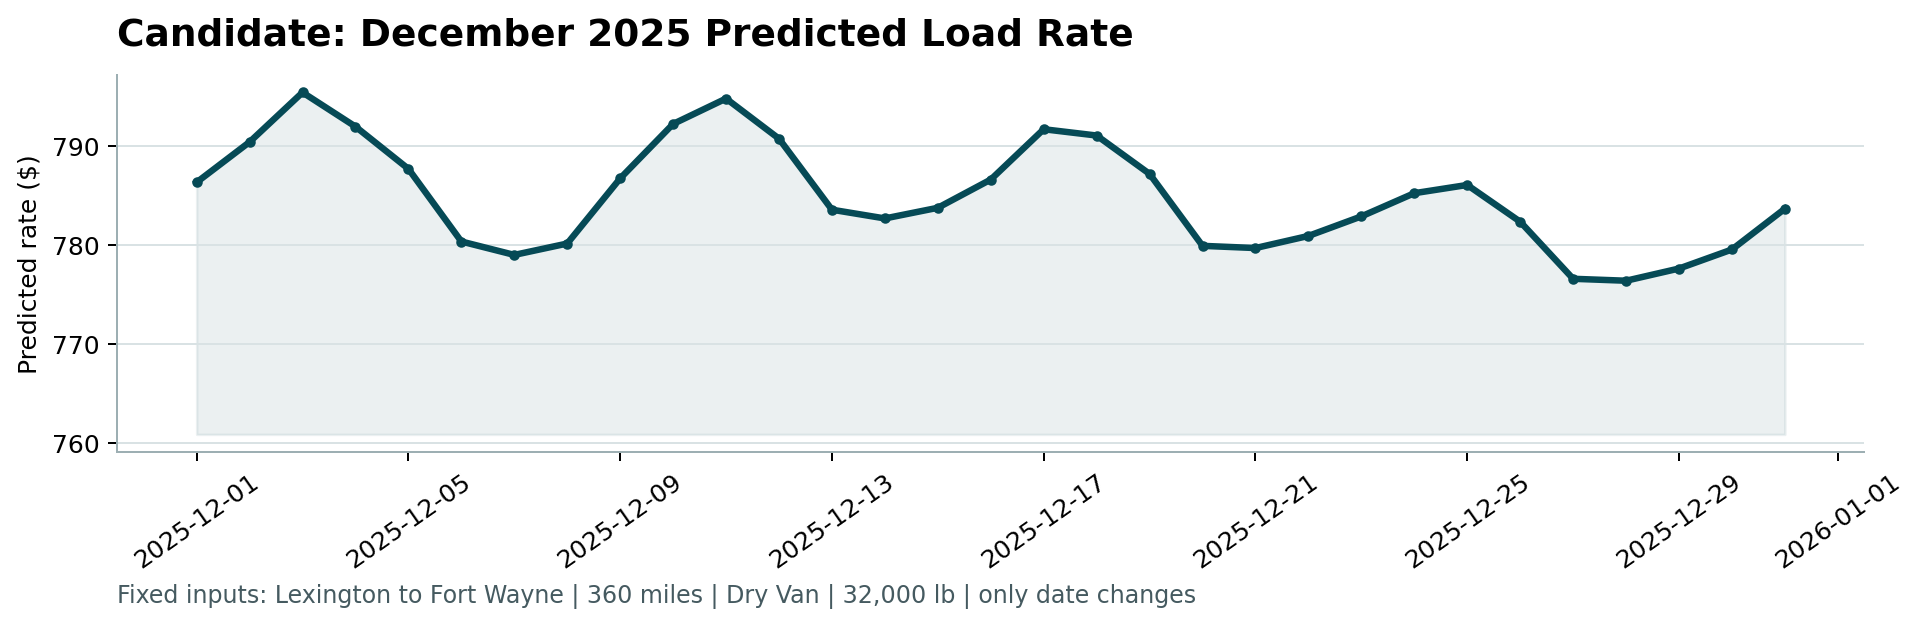

In [30]:
from IPython.display import Image, display

CHART_PATH = "/kaggle/working/scorer_results/candidate_december.png"
display(Image(filename=CHART_PATH))

,feature,importance
0,distance,4030
1,weight_clean,1908
10,doy_cos,1778
9,doy_sin,1343
6,equipment,1333
3,pickup_lon,1158
5,delivery_lon,1150
2,pickup_lat,1066
4,delivery_lat,1059
13,lon_diff,757


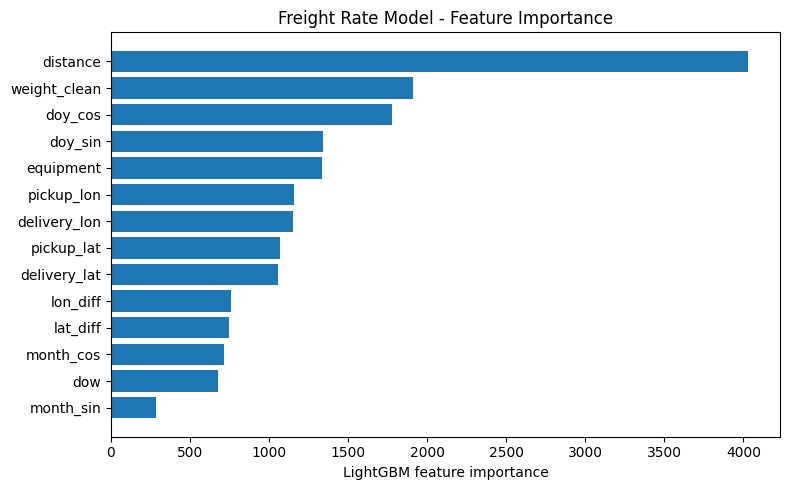

saved: /kaggle/working/feature_importance.png


In [31]:
# Feature importance for the report
importance = (
    pd.DataFrame({
        "feature": FEATURES,
        "importance": final_model.feature_importances_
    })
    .sort_values("importance", ascending=False)
)

display(importance)

plt.figure(figsize=(8, 5))
plt.barh(importance["feature"][::-1], importance["importance"][::-1])
plt.xlabel("LightGBM feature importance")
plt.title("Freight Rate Model - Feature Importance")
plt.tight_layout()

IMPORTANCE_PATH = "/kaggle/working/feature_importance.png"
plt.savefig(IMPORTANCE_PATH, dpi=180, bbox_inches="tight")
plt.show()
print("saved:", IMPORTANCE_PATH)

In [32]:
# Reproducibility file for your GitHub repo
requirements_text = """lightgbm>=4.0,<5
matplotlib>=3.8,<4
numpy>=1.26,<3
pandas>=2.0,<3
scikit-learn>=1.4,<2
"""

REQ_OUTPUT = "/kaggle/working/requirements_submission.txt"
with open(REQ_OUTPUT, "w") as f:
    f.write(requirements_text)

print(requirements_text)
print("saved:", REQ_OUTPUT)

lightgbm>=4.0,<5
matplotlib>=3.8,<4
numpy>=1.26,<3
pandas>=2.0,<3
scikit-learn>=1.4,<2

saved: /kaggle/working/requirements_submission.txt


## What to submit

- GitHub repository with this notebook or equivalent Python scripts, `requirements.txt`, and clear run instructions.
- `validation_predictions.csv`
- PDF/DOCX report describing:
  - problem and data,
  - data-quality findings,
  - preprocessing,
  - chronological split,
  - local MAE/RMSE/MAPE,
  - model choice,
  - feature importance,
  - the supplied scorer's `candidate_december.png`,
  - limitations and possible improvements.
- 2-3 minute Loom walkthrough.

Do **not** claim the local holdout metric is the hidden Spotter score.